In [1]:
import yfinance as yf 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#define tickers
commodity_tickers = {
    'Sugar': 'SB=F',
    'Coffee': 'KC=F',
    'Cocoa': 'CC=F',
    'Soybeans': 'ZS=F',
    'DXY': 'DX-Y.NYB',
}

#for loop for tickers
commodity_data = {}
for name, ticker in commodity_tickers.items():
    commodity_data[name] = yf.Ticker(ticker).history(period="3y")['Close']
#convert to dataframe
df_commodities = pd.DataFrame(commodity_data)

print(df_commodities.head())
display(df_commodities.shape)

                               Sugar      Coffee   Cocoa  Soybeans         DXY
Date                                                                          
2023-07-06 00:00:00-04:00  23.250000  162.350006  3277.0   1525.75  103.169998
2023-07-07 00:00:00-04:00  23.530001  162.800003  3274.0   1485.50  102.269997
2023-07-10 00:00:00-04:00  23.440001  161.750000  3299.0   1508.00  101.970001
2023-07-11 00:00:00-04:00  23.530001  159.300003  3296.0   1520.50  101.730003
2023-07-12 00:00:00-04:00  23.910000  158.750000  3299.0   1488.50  100.519997


(756, 5)

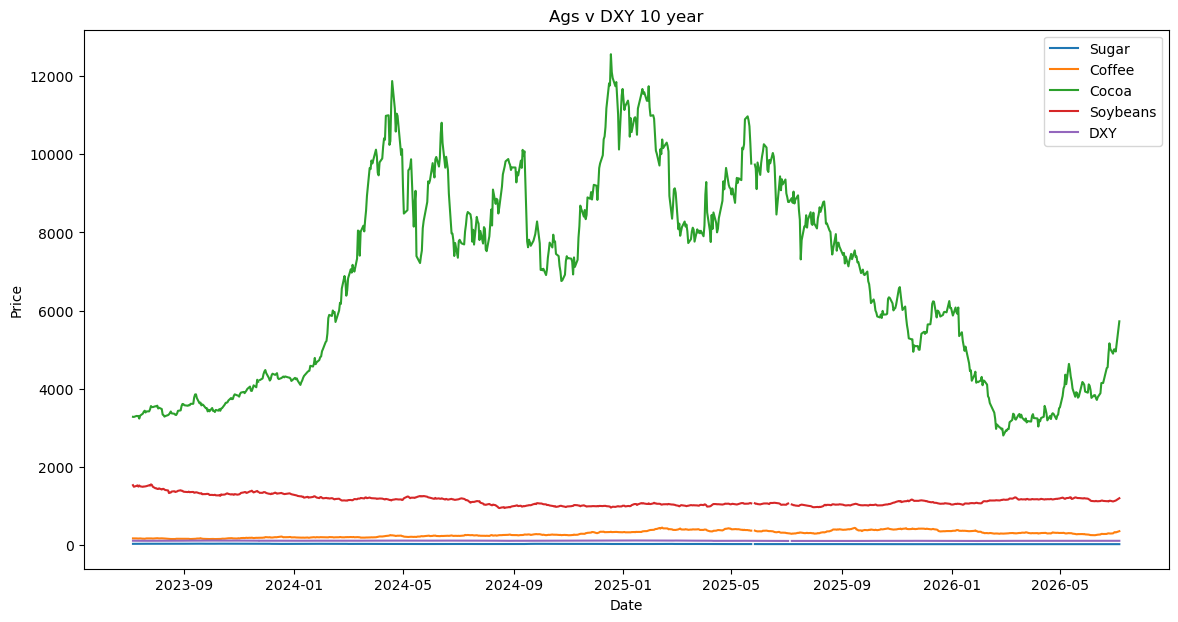

In [3]:
#visualise the results
plt.figure(figsize=(14, 7))
plt.plot(df_commodities)
plt.title('Ags v DXY 10 year')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(df_commodities.columns)
plt.show()

Volatility 

In [5]:
import numpy as np
#Cocoa futures data 
df = yf.download("CC=F", period="2y")
#daily log returns
df['returns'] = np.log(df["Close"]/df["Close"].shift(1))
#daily standard dev
daily_vol = df['returns'].std()
annualized_vol = daily_vol * np.sqrt(252)
print(f"Annualised Cocoa Volatility: {annualized_vol * 100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Annualised Cocoa Volatility: 62.26%


[*********************100%***********************]  1 of 1 completed


<function matplotlib.pyplot.show(close=None, block=None)>

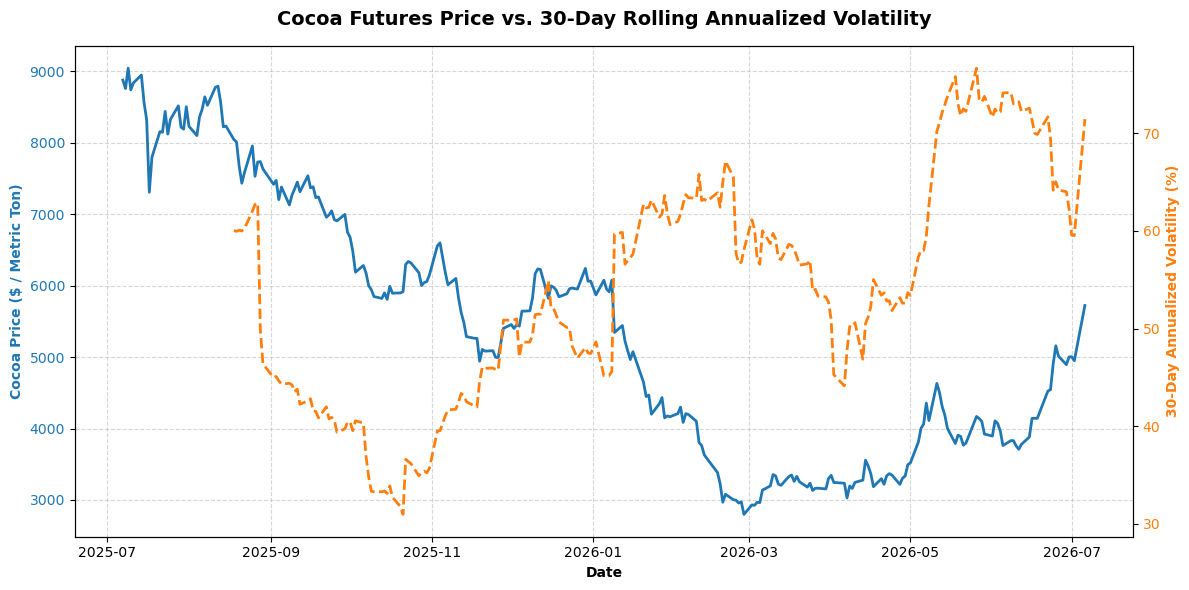

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

# 1. Download cocoa futures data
df = yf.download("CC=F", period="1y")

# 2. Calculate daily log returns and 30-day rolling annualized volatility
df["Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df["Rolling_Vol_30d"] = df["Returns"].rolling(window=30).std() * np.sqrt(252) * 100

# 3. Initialize the plot and the first axis (Price)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Cocoa Price (Left Axis)
color = "#1f77b4"
ax1.set_xlabel("Date", fontweight="bold")
ax1.set_ylabel("Cocoa Price ($ / Metric Ton)", color=color, fontweight="bold")
ax1.plot(df.index, df["Close"], color=color, linewidth=2, label="Cocoa Price")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

# 4. Create a second axis sharing the same x-axis (Volatility)
ax2 = ax1.twinx()
color = "#ff7f0e"
ax2.set_ylabel("30-Day Annualized Volatility (%)", color=color, fontweight="bold")
ax2.plot(
    df.index,
    df["Rolling_Vol_30d"],
    color=color,
    linewidth=2,
    linestyle="--",
    label="30d Volatility",
)
ax2.tick_params(axis="y", labelcolor=color)

# 5. Add titles and render
plt.title(
    "Cocoa Futures Price vs. 30-Day Rolling Annualized Volatility",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
fig.tight_layout()
plt.show

High Volatility While Prices Fall (July 2025 – March 2026)The Trend: Cocoa prices plummeted from roughly $9,000 down to a low near $2,800 per metric ton.The Meaning: Usually, volatility drops when a market calms down. Here, volatility spiked and stayed incredibly high (shifting between 40% and 70%) during the crash. This indicates intense panic-selling, liquidation of massive trading positions, or highly chaotic market reactions to shifting supply reports.

The Late-Stage Volatility Surge (May 2026 – July 2026)The Trend: The orange dashed line surges to its absolute highest level on the chart (over 75% annualized volatility), while the blue price line starts carving out a sharp V-shaped recovery up toward $6,000.The Meaning: This extreme divergence means the market is experiencing structural instability. A 75% annualized volatility rate is exceptionally rare for physical agricultural commodities. It signals that daily price swings are massive and violent. Commercial buyers and chocolate manufacturers are likely struggling to hedge their price risks because the market is moving too fast.

Key Takeaways: The wide gap at the right side of the chart shows that even though prices are lower than they were last summer, the risk profile is actually much higher now. Small supply shocks today will cause much bigger percentage price swings than they did a year ago.Supply Chain Impact: If you are analyzing manufacturing costs, this chart tells you that chocolate companies cannot safely lock in long-term stable pricing right now. The extreme volatility makes raw material budgeting highly unpredictable for Q3 and Q4 of 2026.